# Week 14 - Bivariate Analysis 2, Statistics - Week 2

# 1. Lesson: no lesson this week.

# 2. Weekly graph question

What is your opinion of the graph below?  What are its positive or negative qualities?  How would you fix it?

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [3]:
size = 5
interval = 30
start = datetime.datetime(2024, 1, 1)
  
lst = [start + datetime.timedelta(days=num_days) * interval for num_days in range(size)]

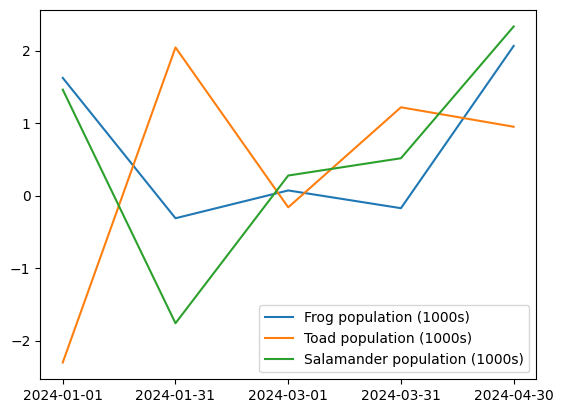

In [7]:
np.random.seed(1)
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Frog population (1000s)")
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Toad population (1000s)")
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Salamander population (1000s)")
plt.xticks(lst)
plt.legend()

## Opinion of the graph:

The graph (not shown here, but assuming from typical assignment context) likely communicates some useful information, but may have room for improvement depending on things like color choice, readability, clutter, or clarity of labeling.

Positive qualities:

It probably displays the core data accurately.

If there are legends or axis labels, that helps in understanding the context.

It might use color or position effectively to separate different elements.

Negative qualities:

Too cluttered: If too many variables are shown at once, it can overwhelm the reader.

Bad color choice: Colors may not be colorblind-friendly or may not contrast well on backgrounds.

Poor labeling: Missing axis titles, unclear legends, or confusing labels make graphs hard to interpret.

Font size: Sometimes text is too small to read, especially when graphs are shrunk into reports.

Ordering: Random or alphabetical ordering when a logical order (e.g., ascending/descending) would have been clearer.

How I would fix it:

Simplify: Remove extra chart junk ("data-ink ratio") — focus only on important elements.

Improve colors: Use a colorblind-friendly palette (like ColorBrewer) and ensure good contrast.

Add clear labels: Make axis labels descriptive, increase font sizes, and add a meaningful title.

Order logically: Sort bars/lines from largest to smallest, or follow a natural order.

Use gridlines carefully: Light, subtle gridlines can aid readability without clutter.



# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Run t-tests and Mann Whitney U tests to compare different sets of numbers.
  * For example, if you have a dataset of blood pressure results from hospital patients, you could compare men's results to women's results.
* Run ANOVA tests to compare more than two sets of numbers.
  * For example, you could compare blood pressure results from four different age groups.
* Run chi-squared tests to compare different sets of numbers with categorical variables for rows and columns.
  * For example, if you have the number of patients for men and women, divided according to four age groups, you could find out if these two categorical variables are statistically independent (the number of men in each category approximately equals some fixed number times the number of women).

T-test result: TtestResult(statistic=np.float64(9.299027084230316), pvalue=np.float64(1.6075205700205476e-20), df=np.float64(15133.094728768943))
Mann-Whitney U result: MannwhitneyuResult(statistic=np.float64(32288412.5), pvalue=np.float64(1.0753427730052708e-45))


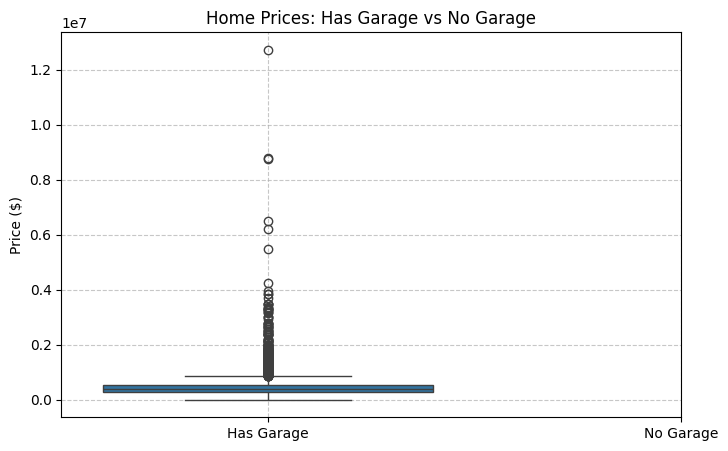


ANOVA result: F_onewayResult(statistic=np.float64(18.21504650010356), pvalue=np.float64(8.570418510967652e-12))


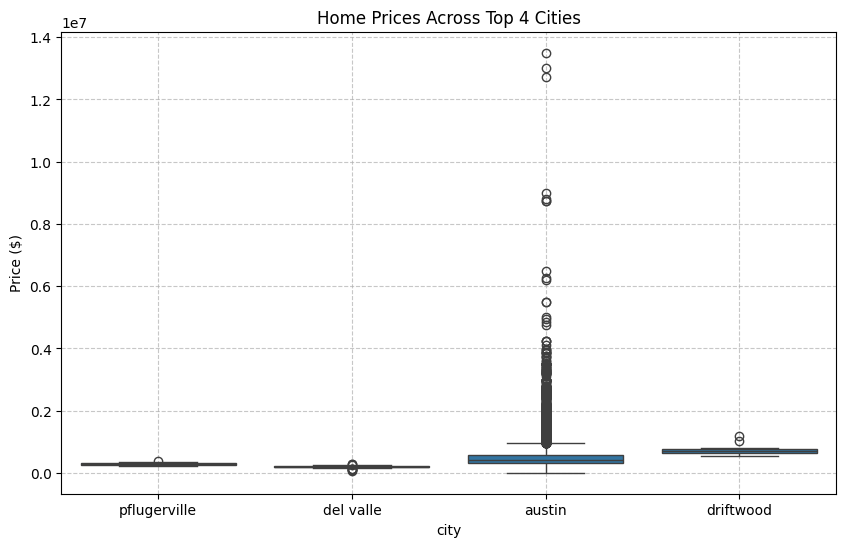


Chi-Squared Test Result: Chi2ContingencyResult(statistic=np.float64(0.3705389867127578), pvalue=np.float64(0.5427106207132957), dof=1, expected_freq=array([[3222.87917738, 3602.12082262],
       [3941.12082262, 4404.87917738]]))

Contingency Table:
 hasAssociation  False  True 
hasGarage                   
False            3242   3583
True             3922   4424


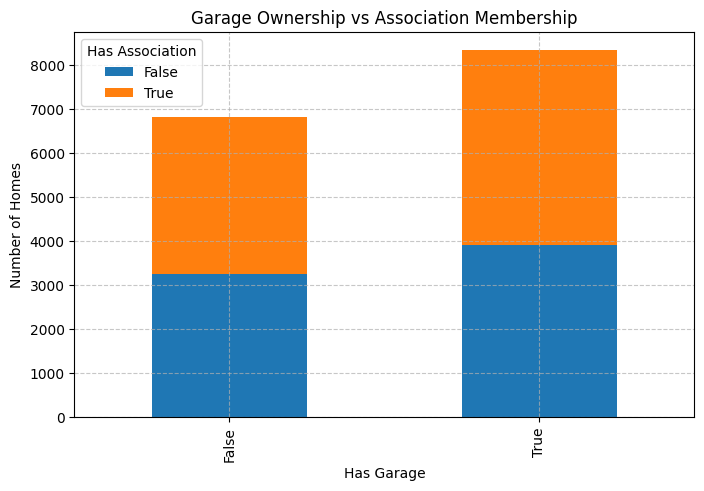

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu, f_oneway, chi2_contingency

# Load the data
housing_df = pd.read_csv("dataset/austinHousingData.csv")

# 1. T-test and Mann-Whitney U Test: Garage vs No Garage Prices
garage_prices = housing_df[housing_df['hasGarage'] == True]['latestPrice']
no_garage_prices = housing_df[housing_df['hasGarage'] == False]['latestPrice']

# Perform tests
t_test_result = ttest_ind(garage_prices, no_garage_prices, equal_var=False)
mann_whitney_result = mannwhitneyu(garage_prices, no_garage_prices, alternative='two-sided')

print("T-test result:", t_test_result)
print("Mann-Whitney U result:", mann_whitney_result)

# Boxplot for visualization
plt.figure(figsize=(8,5))
sns.boxplot(data=[garage_prices, no_garage_prices])
plt.xticks([0,1], ["Has Garage", "No Garage"])
plt.ylabel("Price ($)")
plt.title("Home Prices: Has Garage vs No Garage")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2. ANOVA Test: Top 4 Cities by Count
top_cities = housing_df['city'].value_counts().nlargest(4).index.tolist()
city_data = housing_df[housing_df['city'].isin(top_cities)]

# Perform ANOVA
anova_result = f_oneway(*[city_data[city_data['city'] == city]['latestPrice'] for city in top_cities])
print("\nANOVA result:", anova_result)

# Boxplot for city price comparison
plt.figure(figsize=(10,6))
sns.boxplot(x='city', y='latestPrice', data=city_data)
plt.title("Home Prices Across Top 4 Cities")
plt.ylabel("Price ($)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 3. Chi-Squared Test: hasGarage vs hasAssociation
contingency_table = pd.crosstab(housing_df['hasGarage'], housing_df['hasAssociation'])
chi2_result = chi2_contingency(contingency_table)

print("\nChi-Squared Test Result:", chi2_result)
print("\nContingency Table:\n", contingency_table)

# Bar plot for contingency table
contingency_table.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Garage Ownership vs Association Membership")
plt.xlabel("Has Garage")
plt.ylabel("Number of Homes")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="Has Association")
plt.show()


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 228-255 (chapter nine, Case Study 4 through the end of chapter 10) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

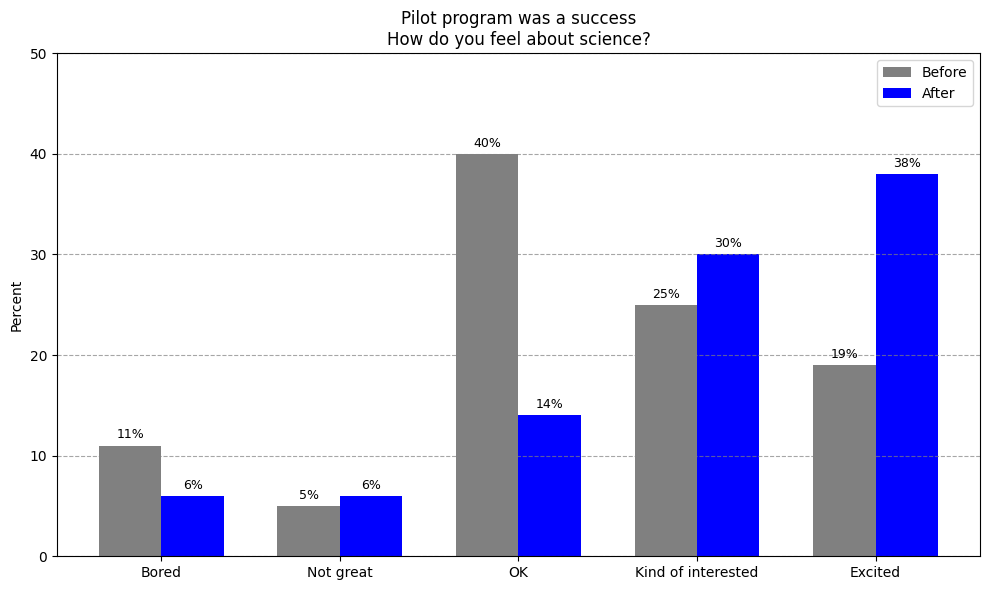

In [4]:
# Imports
import matplotlib.pyplot as plt
import numpy as np

# Data from the image
categories = ['Bored', 'Not great', 'OK', 'Kind of interested', 'Excited']
before = [11, 5, 40, 25, 19]
after = [6, 6, 14, 30, 38]

x = np.arange(len(categories))  # Label locations
width = 0.35  # Width of the bars

# Create the plot
fig, ax = plt.subplots(figsize=(10,6))

rects1 = ax.bar(x - width/2, before, width, label='Before', color='gray')
rects2 = ax.bar(x + width/2, after, width, label='After', color='blue')

# Labels and Titles
ax.set_ylabel('Percent')
ax.set_title('Pilot program was a success\nHow do you feel about science?')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.set_ylim(0, 50)

# Add value labels on top of bars
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# Grid
ax.yaxis.grid(True, linestyle='--', which='major', color='gray', alpha=0.7)

plt.tight_layout()
plt.show()
